In [1]:
## setup
from pathlib import Path
import sys
ROOT_PATH = (Path.cwd().parents[1]).as_posix()

if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)
import numpy as np
from src.model.flow_matching_model import GaussianPriorFlowMatching
from src.config import Config
import yaml
from pathlib import Path
import src.dataset as datasets
import torch
import matplotlib.pyplot as plt
from typing import Optional, Sequence, Tuple, Dict, Callable

WRAPPER_MAP = {
    "GaussianPriorFlowMatching": GaussianPriorFlowMatching,
}

def load_config(path):
    with open(path, "r") as f:
        yaml_dict = yaml.safe_load(f)
    return Config(**yaml_dict)

def load_experiment(folder_path, checkpoint_name):
    config_path = Path(ROOT_PATH)/ Path(folder_path) / Path("config.yaml")
    checkpoint_path = Path(ROOT_PATH)/ Path(folder_path) / Path(checkpoint_name)
    config = load_config(config_path)
    config.data.dataset_folder = str(Path(ROOT_PATH) / Path(config.data.dataset_folder))
    data_module = getattr(datasets, config.data.data_class)(config.data)
    wrapper = WRAPPER_MAP[config.lightning_wrapper](config)
    checkpoint = torch.load(checkpoint_path,map_location="cpu", weights_only="False")
    wrapper.load_state_dict(checkpoint["state_dict"], strict=True)
    return wrapper, data_module


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
## rendering
from scipy.stats import gaussian_kde

def estimate_ar2_coeffs_from_cov(curves):
    """
    curves: numpy array [B, N]
    returns: numpy array [B, 2] with estimated (phi1, phi2)
    """

    # remove burn-in
    x = curves[:]                # [B, N']
    B, N = x.shape

    # center per curve
    x = x - x.mean(axis=1, keepdims=True)

    # autocovariances γ(0), γ(1), γ(2)
    g0 = np.sum(x * x, axis=1) / N
    g1 = np.sum(x[:, 1:] * x[:, :-1], axis=1) / (N - 1)
    g2 = np.sum(x[:, 2:] * x[:, :-2], axis=1) / (N - 2)

    # Build batched Yule–Walker systems A phi = b
    # A[b] = [[g0[b], g1[b]],
    #         [g1[b], g0[b]]]
    A = np.zeros((B, 2, 2))
    A[:, 0, 0] = g0
    A[:, 0, 1] = g1
    A[:, 1, 0] = g1
    A[:, 1, 1] = g0

    b = np.stack([g1, g2], axis=1)[..., None]   # [B, 2, 1]

    # Solve each 2×2 system
    phi = np.linalg.solve(A, b).squeeze(-1)     # [B, 2]
    return phi

def plot_coeff_kde(
    coeffs,
    grid_size=250,
    cmap="viridis",
    title=None,
    ax=None,
    add_colorbar=True,
):
    """
    coeffs: numpy array [B, 2]
    Renders onto the current active axes (or provided ax).
    Returns the AxesImage.
    """
    coeffs = np.asarray(coeffs)

    kde = gaussian_kde(coeffs.T)

    xgrid = np.linspace(-0.2, 0.75, grid_size)
    ygrid = np.linspace(-0.2, 0.75, grid_size)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = kde(positions).reshape(X.shape)

    if ax is None:
        ax = plt.gca()

    img = ax.imshow(
        Z,
        origin="lower",
        extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()],
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=10,
    )

    ax.set_xlabel("phi1")
    ax.set_ylabel("phi2")
    if title is not None:
        ax.set_title(title)

    if add_colorbar:
        plt.colorbar(img, ax=ax)

    return img

Wasserstein distance: 0.0284 ± 0.0025


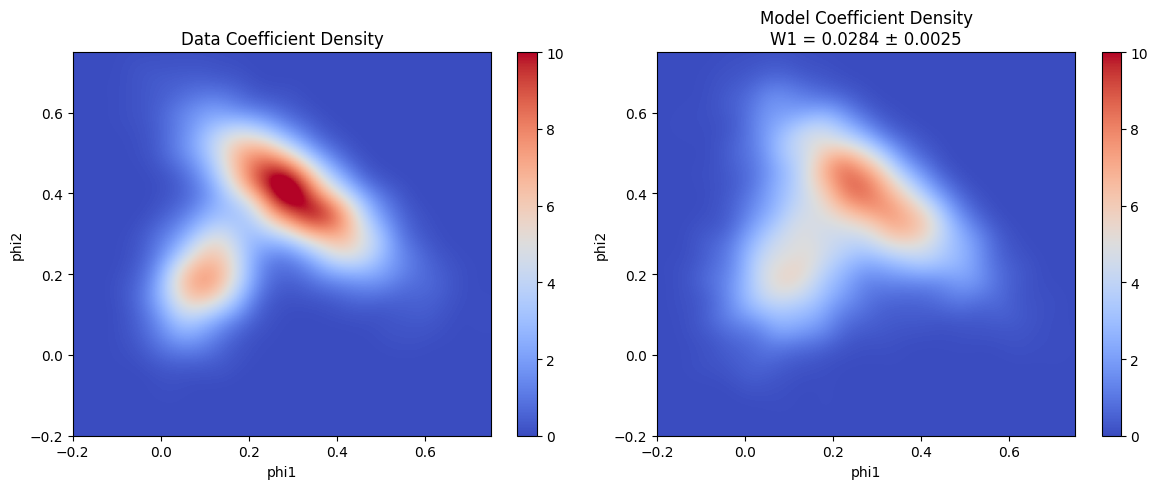

In [6]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def empirical_wasserstein_2d(x, y, max_points=2000, seed=0):
    """
    Empirical Wasserstein-1 distance between two 2D point clouds.
    """
    rng = np.random.default_rng(seed)

    x = np.asarray(x)
    y = np.asarray(y)

    n = min(len(x), len(y), max_points)

    x = x[rng.choice(len(x), n, replace=False)]
    y = y[rng.choice(len(y), n, replace=False)]

    C = cdist(x, y, metric="euclidean")

    row_ind, col_ind = linear_sum_assignment(C)

    return C[row_ind, col_ind].mean()


## load model
folder_path = "outputs/gaussian prior - drw ar2"

# step = "099500"
# step = "097500"
# step = "093000"
# step = "092500"
# step = "092000"
# step = "090500"
# step = "089000"
step = "050000"

checkpoint_name = f"step=step={step:}.ckpt"

model_wrapper, data_module = load_experiment(folder_path, checkpoint_name)
model_wrapper.to("cuda")

## data estimated coefficients
num_curves = 8000

model_samples = model_wrapper.sample(num_curves)
dataset_samples = data_module.get_reference_curves(None)

data_coeffs = estimate_ar2_coeffs_from_cov(
    dataset_samples.cpu().numpy()[
        np.random.permutation(dataset_samples.shape[0])
    ][:num_curves]
)

model_coeffs = estimate_ar2_coeffs_from_cov(
    model_samples.cpu().numpy().squeeze()
)

## Wasserstein distance
wasserstein_vals = [
    empirical_wasserstein_2d(
        data_coeffs,
        model_coeffs,
        max_points=2000,
        seed=i,
    )
    for i in range(10)
]

wasserstein_mean = np.mean(wasserstein_vals)
wasserstein_std = np.std(wasserstein_vals)

print(
    f"Wasserstein distance: "
    f"{wasserstein_mean:.4f} ± {wasserstein_std:.4f}"
)

## plot
plt.figure(figsize=(12, 5))

plt.subplot(121)
plot_coeff_kde(data_coeffs, cmap="coolwarm")
plt.title("Data Coefficient Density")

plt.subplot(122)
plot_coeff_kde(model_coeffs, cmap="coolwarm")
plt.title(
    "Model Coefficient Density\n"
    f"W1 = {wasserstein_mean:.4f} ± {wasserstein_std:.4f}"
)

plt.tight_layout()

plt.savefig("fig.png", dpi=500)

plt.show()